In [28]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

print("Libraries imported successfully! Ready for the data.")

Libraries imported successfully! Ready for the data.


In [29]:
df = pd.read_csv('titanic.csv')
print("Sucess")

Sucess


In [30]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [32]:
# age has missing values
# emabarked has missing values
# deck has only 203 values other are missing, we should drop it

In [33]:
df.shape

(891, 15)

# **Handling Missing Values**

In [36]:
df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df.drop(columns=['deck'], inplace=True)

In [38]:
df.drop(columns=['alive', 'class', 'who', 'adult_male', 'embark_town'], inplace=True)

KeyError: "['alive', 'class', 'who', 'adult_male', 'embark_town'] not found in axis"

# **Feature Engineering**

In [40]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

In [41]:
df.drop(columns=['sibsp', 'parch'], inplace=True)

In [42]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df['alone'] = df['alone'].astype(int)

In [43]:
print(df.head())

   survived  pclass  sex   age     fare  embarked  alone  family_size
0         0       3    0  22.0   7.2500         0      0            2
1         1       1    1  38.0  71.2833         1      0            2
2         1       3    1  26.0   7.9250         0      1            1
3         1       1    1  35.0  53.1000         0      0            2
4         0       3    0  35.0   8.0500         0      1            1


In [44]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   fare         891 non-null    float64
 5   embarked     891 non-null    int64  
 6   alone        891 non-null    int64  
 7   family_size  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB
None


In [47]:
print(f"Duplicate rows found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Duplicate rows found: 112


In [48]:
print(df.describe())

         survived      pclass         sex         age        fare    embarked  \
count  779.000000  779.000000  779.000000  779.000000  779.000000  779.000000   
mean     0.412067    2.245186    0.373556   29.797727   34.845116    0.346598   
std      0.492523    0.854573    0.484059   13.717690   52.295104    0.613074   
min      0.000000    1.000000    0.000000    0.420000    0.000000    0.000000   
25%      0.000000    1.000000    0.000000   21.500000    8.050000    0.000000   
50%      0.000000    3.000000    0.000000   29.699118   15.900000    0.000000   
75%      1.000000    3.000000    1.000000   36.000000   34.375000    1.000000   
max      1.000000    3.000000    1.000000   80.000000  512.329200    2.000000   

            alone  family_size  
count  779.000000   779.000000  
mean     0.567394     1.942234  
std      0.495756     1.520384  
min      0.000000     1.000000  
25%      0.000000     1.000000  
50%      1.000000     1.000000  
75%      1.000000     2.000000  
max   

# **Visualizations**

In [49]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

**Survival by Gender**

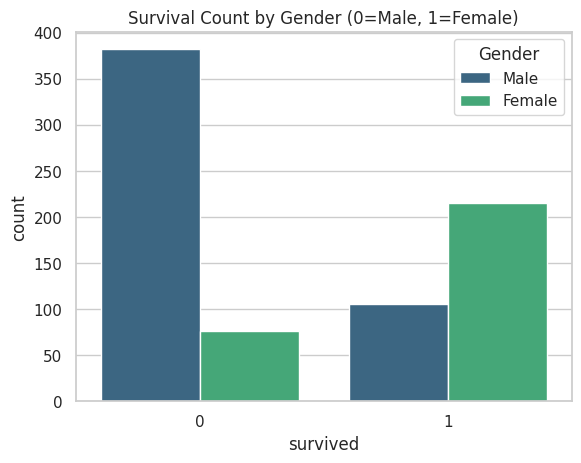

In [54]:
sns.countplot(data=df, x='survived', hue='sex', palette='viridis')
plt.title('Survival Count by Gender (0=Male, 1=Female)')
plt.legend(title='Gender', labels=['Male', 'Female'])

**Survival by Class**

Text(0.5, 1.0, 'Survival Rate by Passenger Class')

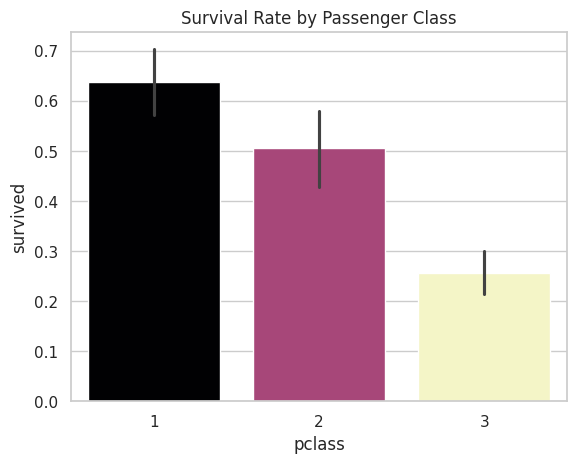

In [56]:
sns.barplot(data=df, x='pclass', y='survived', hue='pclass', palette='magma', legend=False)
plt.title('Survival Rate by Passenger Class')

**Age Dsitribution**

Text(0.5, 1.0, 'Age Distribution of Survival')

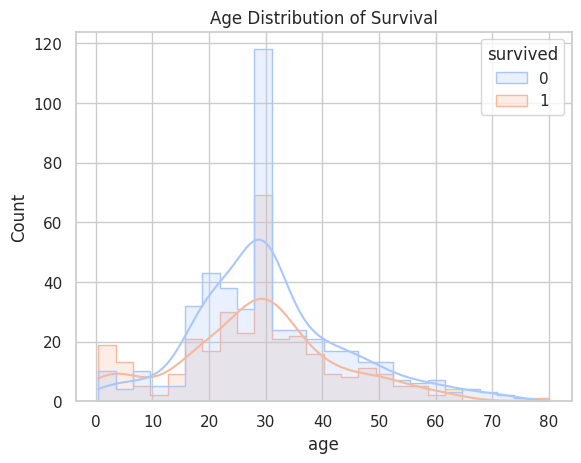

In [57]:
sns.histplot(data=df, x='age', hue='survived', kde=True, element="step", palette='coolwarm')
plt.title('Age Distribution of Survival')

**Survival by Family**

Text(0.5, 1.0, 'Survival Probability vs Family Size')

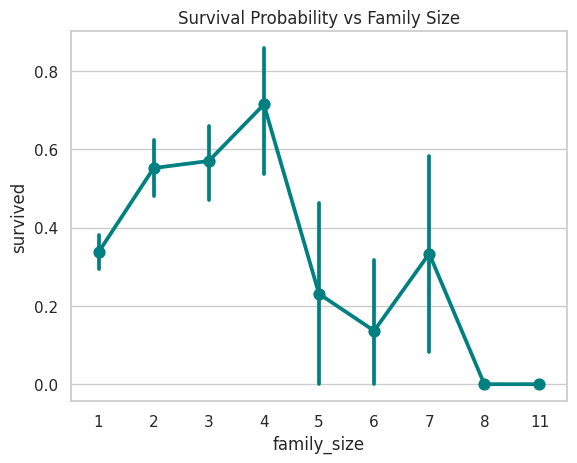

In [58]:
sns.pointplot(data=df, x='family_size', y='survived', color='teal')
plt.title('Survival Probability vs Family Size')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

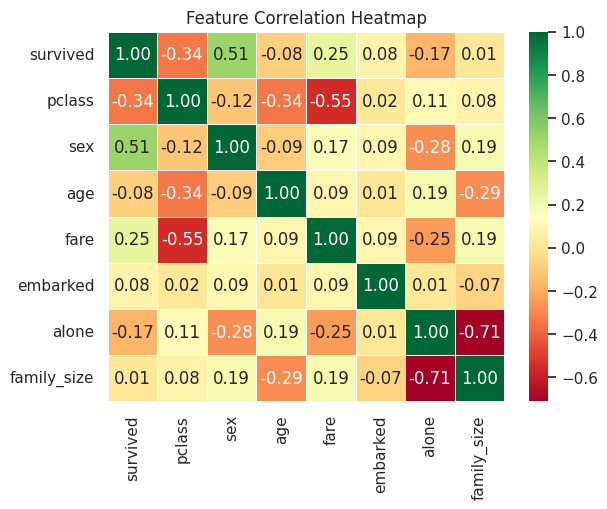

In [62]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')

**Building Model**

In [67]:
X = df.drop(columns=['survived'])
y = df['survived']

print(f"Features being used: {X.columns.tolist()}")

Features being used: ['pclass', 'sex', 'age', 'fare', 'embarked', 'alone', 'family_size']


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training records: {len(X_train)}")
print(f"Testing records: {len(X_test)}")

Training records: 623
Testing records: 156


In [66]:
model = LogisticRegression(max_iter=1000)

Accuracy: 0.8397435897435898


In [69]:
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [71]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")

Final Model Accuracy: 83.97%


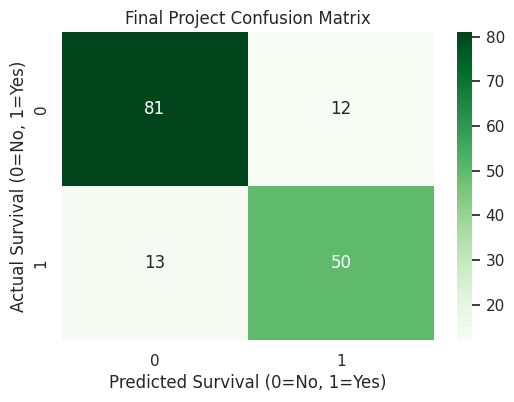

In [72]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Final Project Confusion Matrix')
plt.xlabel('Predicted Survival (0=No, 1=Yes)')
plt.ylabel('Actual Survival (0=No, 1=Yes)')
plt.show()